In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# grab the normalized per chip, arcsinh transformed data
df = pd.read_csv("../data/normalized-perchip-arcsinh.csv", index_col=0)
display(df)

,10000_at,10001_at,10002_i_at,10003_f_at,10004_at,10005_at,10006_at,10007_at,10008_at,10009_at,...,9990_at,9991_at,9992_at,9993_at,9994_at,9995_at,9996_at,9997_at,9998_at,9999_at
GSM77298,0.055339,1.437047,2.520894,3.803361,0.005650,1.533861,0.614774,1.918247,0.025986,0.309175,...,1.178673,0.079014,0.487771,1.266814,3.685886,1.585712,4.093568,2.347292,0.136301,2.288447
GSM77299,0.073751,1.351225,2.436446,3.097790,0.004614,1.398911,0.598074,2.038964,0.028831,0.088696,...,1.493072,0.118523,0.350344,1.754934,3.269344,1.169223,4.554970,2.056239,0.236542,2.491590
GSM77300,0.119759,0.997280,2.739272,3.679443,0.049810,1.594438,0.615066,1.982846,0.190243,0.166835,...,1.306491,0.071287,0.414943,1.427824,3.668934,1.362803,4.725811,2.231584,0.175764,2.492338
GSM77301,0.054967,0.980137,2.785481,3.553888,0.013468,1.369467,0.811451,2.034463,0.155379,0.084076,...,1.466488,0.127600,0.549871,1.665212,3.770282,1.160348,4.587313,1.850947,0.194066,2.309352
GSM77302,0.030197,0.836380,2.813253,3.535727,0.004474,1.315025,0.966502,1.860060,0.017896,0.190128,...,1.497345,0.086024,0.317885,0.773877,3.537029,1.138892,4.341968,1.980670,0.167008,2.127815
GSM77303,0.025971,0.826778,2.699219,3.599009,0.030298,1.373747,0.877542,1.933411,0.038951,0.156289,...,1.428039,0.081080,0.697471,1.633885,3.867119,1.058365,3.878191,1.560221,0.146660,1.962445
GSM77304,0.012973,0.761114,2.613701,3.659863,0.006486,1.291188,0.927984,1.706019,0.030266,0.272298,...,1.514344,0.112197,0.759455,1.711327,3.910779,1.252416,3.998844,1.744466,0.192326,2.030064
GSM77305,0.091349,0.924795,2.861251,3.866385,0.008316,1.445029,0.893814,1.654158,0.064405,0.346458,...,1.613508,0.118227,0.891627,1.706559,4.059844,1.288954,3.424599,1.738230,0.106865,1.868203
GSM77306,0.088157,1.883680,3.094087,4.604133,0.012092,1.871753,1.790942,1.022613,0.111017,0.405930,...,1.797983,0.102601,0.932581,0.364318,4.626182,1.495408,3.471977,2.144238,0.112219,1.859690
GSM77307,0.062599,1.270484,2.776888,4.196536,0.005593,1.409092,0.472189,1.372392,0.027961,0.277197,...,1.326730,0.077105,0.382131,1.045145,4.113193,1.650963,3.803873,1.540347,0.071527,2.008170


In [90]:
# get a list of periodic genes
periodic = pd.read_csv("../data/periodic-normalized-perchip-arcsinh.csv", index_col=0, nrows=0).columns.tolist()
y = np.array([1 if col in periodic else 0 for col in df.columns], dtype=np.bool)
print(y)

[False  True False ...  True  True  True]


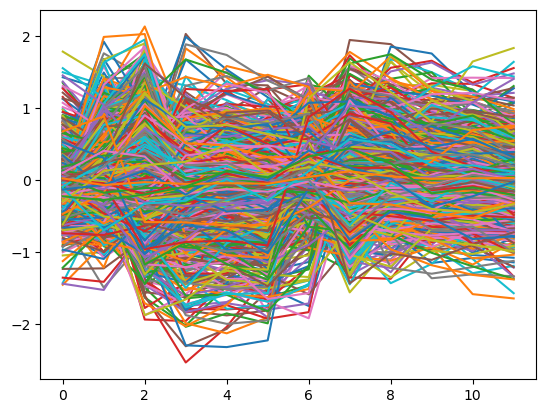

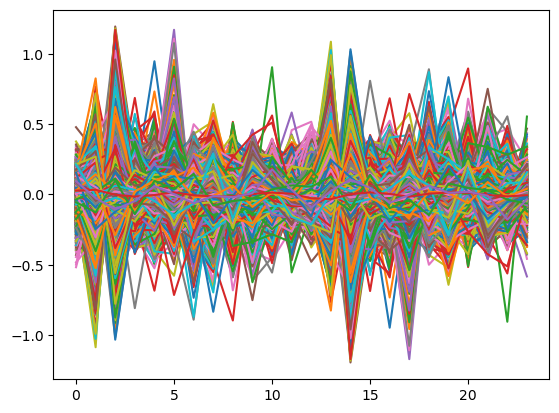

In [ ]:
# get the length-m symmetric moving average about z_t for l <= t <= N - l
Z = df.values.copy()

# classical TS parameters
l = 6
m = l * 2
N = 36

# get moving average
tvals = np.arange(l, N - l)
T = np.zeros((N - 2 * l, len(y)))
for t in tvals:
    section = Z[t - l:t + l + 1].copy()
    section[0] /= 2
    section[-1] /= 2
    T[t - l] = np.sum(section, axis=0)
T /= m

# get detrended series over the detrended two periods
Y = Z[tvals] - T

# get the seasonal component
modmask = np.tile(np.arange(len(Y)) % m, (m, 1)).T == np.arange(m)
S = np.einsum('ij,ik->jk', modmask, Y) / 2

# plot s for kicks and giggles
# plt.plot(np.arange(3 * m), Z)
# plt.show()
# plt.plot(np.arange(2 * m), T)
# plt.show()
# plt.plot(np.arange(2 * m), Y)
# plt.show()
# plt.plot(np.arange(m), S[:, y])
# plt.show()
# plt.plot(np.arange(2 * m), Z[tvals] - T - np.tile(S, (2, 1)))
# plt.show()

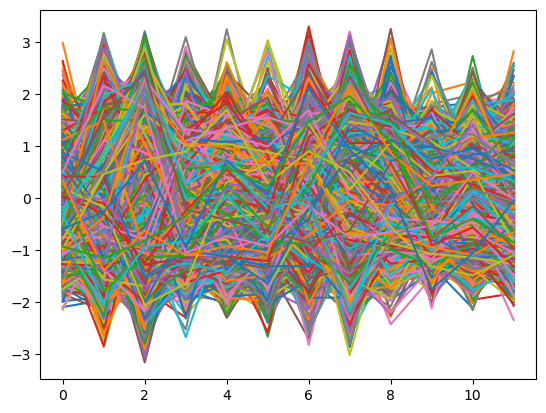

 ...]

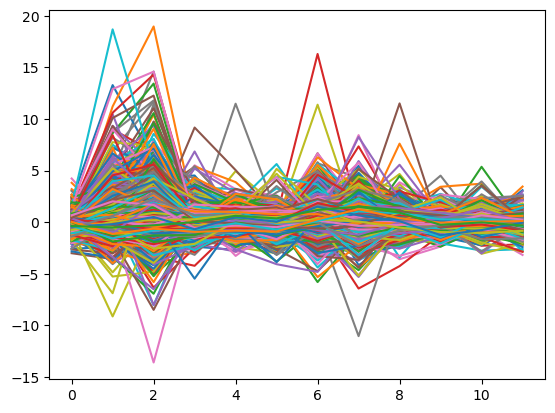

In [70]:
from sklearn.preprocessing import StandardScaler, RobustScaler

scaled_S = StandardScaler().fit_transform(S)
robscaled_S = RobustScaler().fit_transform(S)

plt.plot(np.arange(m), scaled_S[:, y])
plt.show()
plt.plot(np.arange(m), robscaled_S[:, y])

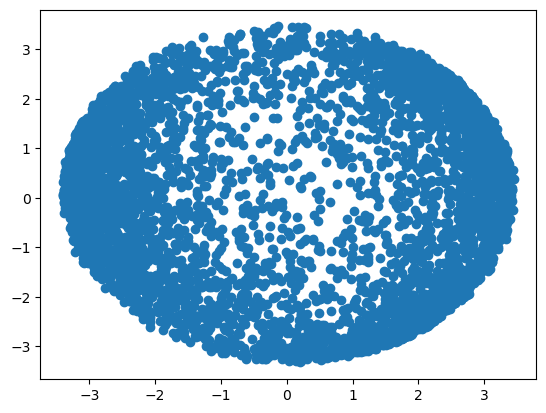

In [72]:
from sklearn.decomposition import PCA

Spca = PCA(n_components=2).fit_transform(scaled_S[:, y].T)

plt.scatter(*Spca.T)

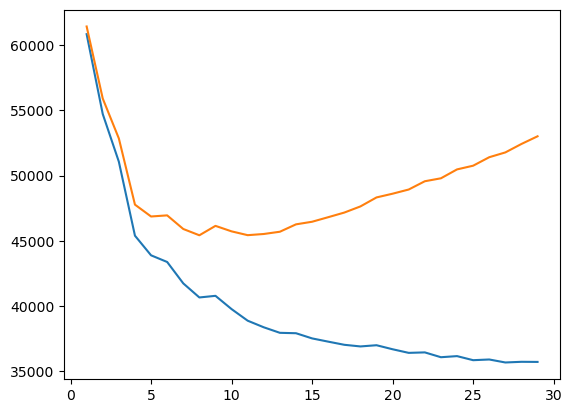

In [83]:
from sklearn.mixture import GaussianMixture

aics = list()
bics = list()
preds = list()

Xfit = scaled_S[:, y].T

ncs = np.arange(1, 30)
for nc in ncs:
    gm = GaussianMixture(n_components=nc).fit(Xfit)
    aics.append(gm.aic(Xfit))
    bics.append(gm.bic(Xfit))
    preds.append(gm.predict_proba(Xfit))

plt.plot(ncs, aics, label="aics")
plt.plot(ncs, bics, label="bics")

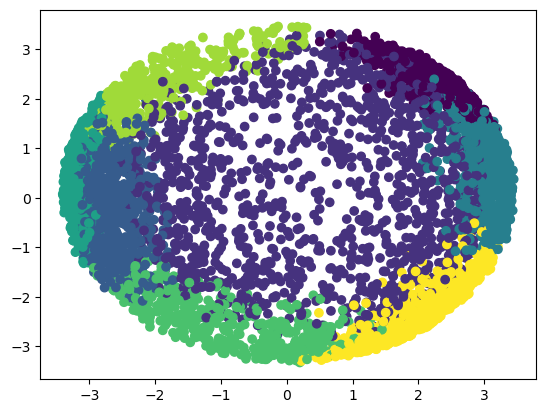

In [89]:
# let's try 8 clusters
ypred = preds[7]
ypredargs = np.argmax(ypred, axis=1)
# display(y)

plt.scatter(*Spca.T, c=ypredargs)

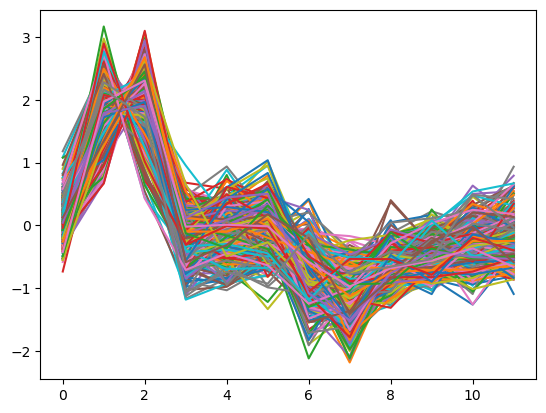

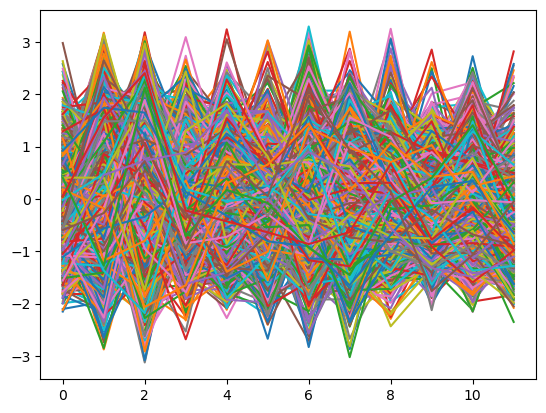

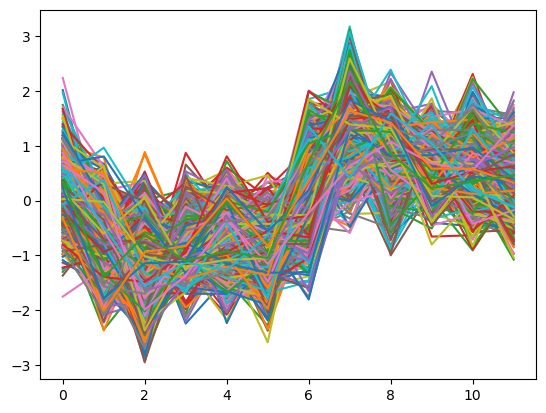

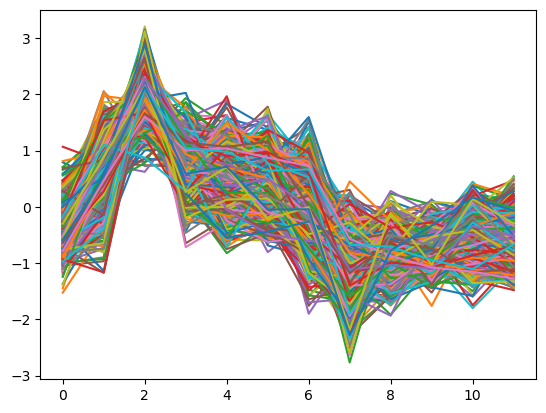

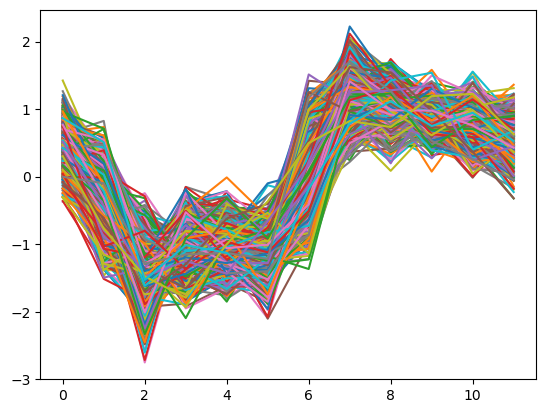

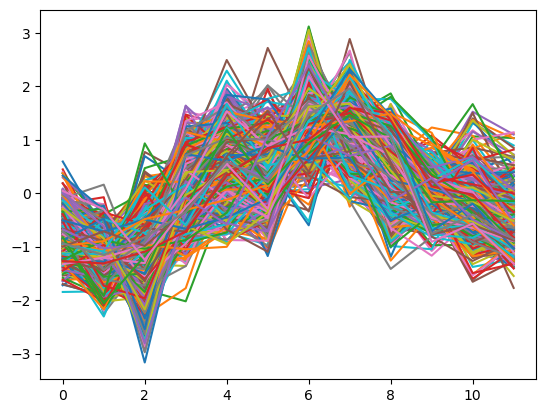

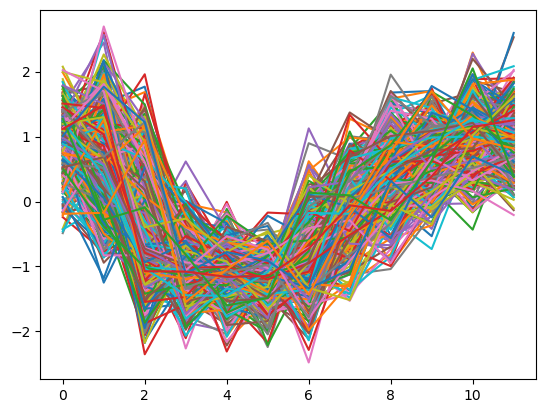

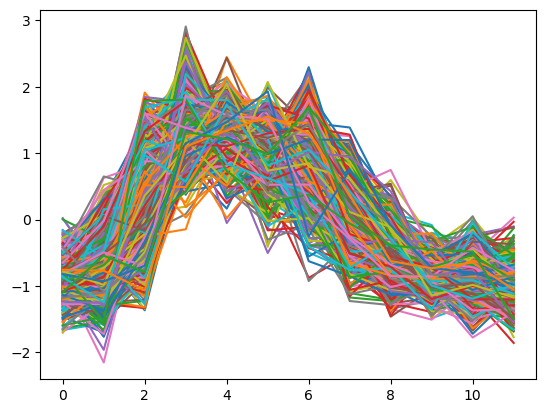

In [95]:
for c in np.arange(0, np.max(ypredargs) + 1):
    Xperi = scaled_S[:, y].copy()
    plotmask = ypredargs == c
    Xplot = Xperi[:, plotmask]
    plt.plot(np.arange(12), Xplot)
    plt.show()

TODO:
- Reject those points in the second cluster because it looks just like noise, focus again on the clearly periodic stuff
- Perform another UMAP and PCA just with the raw data from those points to clear up things even more
- Sort the sequences from each cluster in terms of maximal likelihood / probability, to identify the strongest representatives of each class
- plot error bars around averages of each sequence
- correspond the sequence plots and the graph and show the order matches ??
- slurp the metadata and try and find the meaning of each module - maybe feed the proteins to Claude AI and have it try and find or fail to find a biological explanation, at least make sure to join with the metadata CSV
- then we can compare these clusters with the other models as a baseline.

In [107]:
allgenesidx = np.arange(len(y))
perigenesidx = allgenesidx[y]
perigenesclust = np.stack([perigenesidx, ypredargs], axis=1)
nonoiseidx = ypredargs != 1
perigenesnonoise = perigenesclust[nonoiseidx]
display(perigenesnonoise)
display(df.T.iloc[perigenesnonoise[:,0]])
mydf = df.T.iloc[perigenesnonoise[:,0]]
mydf["labels"] = perigenesnonoise[:, 1]
mydf = mydf[["labels"]]
mydf.to_csv("classical_ts__s__gmm_clustered__visible_signal.csv")

array([[   1,    7],
       [   3,    3],
       [   5,    3],
       ...,
       [9271,    2],
       [9273,    2],
       [9274,    5]])

,GSM77298,GSM77299,GSM77300,GSM77301,GSM77302,GSM77303,GSM77304,GSM77305,GSM77306,GSM77307,...,GSM77324,GSM77325,GSM77326,GSM77327,GSM77328,GSM77329,GSM77330,GSM77331,GSM77332,GSM77333
10001_at,1.437047,1.351225,0.997280,0.980137,0.836380,0.826778,0.761114,0.924795,1.883680,1.270484,...,1.050237,0.891368,0.887193,0.774625,0.861921,1.970621,1.656134,1.573671,1.706939,1.803642
10003_f_at,3.803361,3.097790,3.679443,3.553888,3.535727,3.599009,3.659863,3.866385,4.604133,4.196536,...,3.602857,3.440328,3.561384,3.630543,3.800901,4.394373,4.054006,3.730895,3.748445,3.772102
10005_at,1.533861,1.398911,1.594438,1.369467,1.315025,1.373747,1.291188,1.445029,1.871753,1.409092,...,1.436538,1.329286,1.240209,1.348405,1.422917,1.809440,1.557465,1.561141,1.727630,1.768271
10010_at,4.087141,3.974576,4.162059,3.803687,3.442702,3.058513,3.396971,3.214069,3.307293,3.716888,...,3.864080,3.533334,3.269016,3.457854,3.471743,3.349254,3.950183,3.751380,3.959832,3.969010
10011_at,0.260326,0.116232,0.169069,0.150941,0.148226,0.076764,0.161460,0.100662,0.176828,0.203295,...,0.242805,0.116253,0.104962,0.120130,0.142685,0.144991,0.250119,0.190809,0.291229,0.370591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992_at,0.487771,0.350344,0.414943,0.549871,0.317885,0.697471,0.759455,0.891627,0.932581,0.382131,...,0.511822,0.338963,0.600388,0.557117,0.506965,1.132667,0.591767,0.430282,0.448520,0.443950
9994_at,3.685886,3.269344,3.668934,3.770282,3.537029,3.867119,3.910779,4.059844,4.626182,4.113193,...,3.773198,3.540522,3.811130,3.949760,3.339223,4.464466,4.264264,3.832299,3.940158,3.935605
9996_at,4.093568,4.554970,4.725811,4.587313,4.341968,3.878191,3.998844,3.424599,3.471977,3.803873,...,4.547198,4.410960,4.309221,4.290862,3.983282,3.434828,4.060665,3.874688,3.990781,4.005935
9998_at,0.136301,0.236542,0.175764,0.194066,0.167008,0.146660,0.192326,0.106865,0.112219,0.071527,...,0.195365,0.144381,0.139751,0.156429,0.140521,0.086206,0.092864,0.071438,0.078548,0.108259


In [112]:
mydf["probabilities"] = ypred.max(axis=1)[nonoiseidx]
display(mydf)

,labels,probabilities
10001_at,7,0.857061
10003_f_at,3,0.999703
10005_at,3,0.997951
10010_at,5,0.986816
10011_at,7,0.701117
...,...,...
9992_at,0,0.993806
9994_at,3,0.998811
9996_at,2,0.966032
9998_at,2,0.993418


In [113]:
mydf.to_csv("classical_ts__s__gmm_clustered__visible_signal.csv")